# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 10

### Zadanie 1

W okolicy znajdują się **trzy obozy**. Nie znamy liczby uczestników, ale posiadamy dane o ich zamówieniach na dwa produkty:

- **woda** (w litrach),  
- **kawa** (w sztukach).


1. Wyświetl dane na wykresie punktowym, gdzie:
   - oś **X** przedstawia zamówienia na **wodę**,
   - oś **Y** przedstawia zamówienia na **kawę**.  
   Każdy obóz powinien być reprezentowany jako punkt na wykresie.

2. **Dodaj linie** prowadzące z punktu **(0, 0)** do każdego z punktów reprezentujących obozy.

3. **Oblicz** między każdą parą obozów:
   - **odległości [Euklidesowe](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html)**,
   - **odległości [kosinusowe](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html)**.

4. **Wskaż parę obozów najbardziej podobnych do siebie** (na podstawie jednej lub obu metryk).

Dane wejściowe:


| Nazwa obozu     | Zamówienia na wodę (w l.) | Zamówienia na kawę (w szt.) |
| :---            | ---                       | --- |
| Obóz sportowy 1 | 200 | 25  |
| Obóz sportowy 2 | 900 | 80  |
| Obóz szachowy   | 300 | 120 |



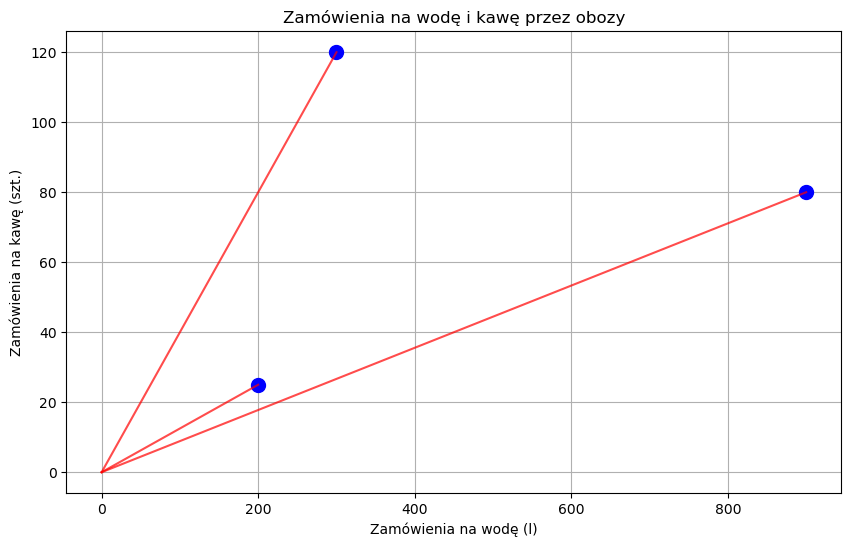

Odległości Euklidesowe między obozami:
Obóz sportowy 1 <-> Obóz sportowy 2: 702.16
Obóz sportowy 1 <-> Obóz szachowy: 137.93
Obóz sportowy 2 <-> Obóz szachowy: 601.33

Odległości kosinusowe między obozami:
Obóz sportowy 1 <-> Obóz sportowy 2: 0.0006
Obóz sportowy 1 <-> Obóz szachowy: 0.0326
Obóz sportowy 2 <-> Obóz szachowy: 0.0423

Najbardziej podobne obozy wg odległości Euklidesa: ('Obóz sportowy 1', 'Obóz szachowy') (odl. 137.93)
Najbardziej podobne obozy wg odległości kosinusowej: ('Obóz sportowy 1', 'Obóz sportowy 2') (odl. 0.0006)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import euclidean, cosine
from itertools import combinations

water = np.array([200, 900, 300])
coffee = np.array([25, 80, 120])
camp_names = ['Obóz sportowy 1', 'Obóz sportowy 2', 'Obóz szachowy']
orders = np.column_stack((water, coffee))

plt.figure(figsize=(10, 6))
plt.plot(water, coffee, 'o', markersize=10, color='blue', label='Obozy')

for x, y in zip(water, coffee):
    plt.plot([0, x], [0, y], 'r-', alpha=0.7)

plt.xlabel('Zamówienia na wodę (l)')
plt.ylabel('Zamówienia na kawę (szt.)')
plt.title('Zamówienia na wodę i kawę przez obozy')
plt.grid(True)
plt.show()

eucl_dist = {}
cos_dist = {}

for (i, j) in combinations(range(3), 2):
    eucl = euclidean(orders[i], orders[j])
    cos = cosine(orders[i], orders[j])
    eucl_dist[(camp_names[i], camp_names[j])] = eucl
    cos_dist[(camp_names[i], camp_names[j])] = cos

print("Odległości Euklidesowe między obozami:")
for k, v in eucl_dist.items():
    print(f"{k[0]} <-> {k[1]}: {v:.2f}")

print("\nOdległości kosinusowe między obozami:")
for k, v in cos_dist.items():
    print(f"{k[0]} <-> {k[1]}: {v:.4f}")

min_eucl = min(eucl_dist, key=eucl_dist.get)
min_cos = min(cos_dist, key=cos_dist.get)

print(f"\nNajbardziej podobne obozy wg odległości Euklidesa: {min_eucl} (odl. {eucl_dist[min_eucl]:.2f})")
print(f"Najbardziej podobne obozy wg odległości kosinusowej: {min_cos} (odl. {cos_dist[min_cos]:.4f})")


### Zadanie 2

#### A)

Mamy dane dotyczące kilku parków narodowych. Chcielibyśmy wykorzystać poznane w poprzednim zadaniu miary podobieństwa w celu odnalezienia najbardziej podobnych parków na podstawie pewnych szacunkowych pomiarów liczby drzew (iglastych i liściastych) oraz populacji kilku gatunków zwierząt. 

  

1. Dla każdej pary parków oblicz odległość Euklidesową i kosinusową. 
2. Wskaż parę najbardziej podobnych parków (dla każdej metryki osobno).  
4. Na podstawie uzyskanych wyników odpowiedz na pytanie która miara lepiej oddaje podobieństwo między parkami? Uzasadnij swoją opinię.
5. Znajdź park najbardziej podobny do Tatrzańskiego Parku Narodowego? 

Szacunkowe dane:

| Nazwa                                       | Liczba drzew iglastych | Liczba drzew liściastych | Liczba dzików | Liczba wilków | Liczba niedźwiedzi | Liczba jeleni |
| ---                                         | ---      | ---    |--- |--- | --- | ---  |
|Tatrzański Park Narodowy (Polska)            |   1000000|  200000|  90|  75|   50|  1200|
|Białowieski Park Narodowy (Polska)           |    250000| 1100000| 250|  40|    0|  1000|
|Yellowstone National Park (Stany Zjednoczone)|  30000000| 1000000|   0| 120| 1200| 30000|
|Banff National Park (Kanada)                 | 110000000| 7000000|   0|  40|  120|  5000|
|Nadbajkalski Park Narodowy (Rosja)           |   8000000| 2100000| 700| 550|  225|  6000|

#### B)

Co można zrobić, aby odległość Euklidesa zwracała wyniki podobne do kosinusowej? Wykonaj zadanie ponownie uzyskując inne (być może "lepsze") wyniki dla metryki Euklidesa niż w podzadaniu A.

In [ ]:
import math
import pandas as pd

park_names = [
    "Tatrzański Park Narodowy (Polska)",
    "Białowieski Park Narodowy (Polska)",
    "Yellowstone National Park (Stany Zjednoczone)",
    "Banff National Park (Kanada)",
    "Nadbajkalski Park Narodowy (Rosja)"
]

parks_data = np.array([
    [1000000,  200000,   90,  75,   50,  1200],
    [ 250000, 1100000,  250,  40,    0,  1000],
    [30000000, 1000000,   0, 120, 1200, 30000],
    [110000000, 7000000, 0,  40,  120,  5000],
    [8000000, 2100000, 700, 550, 225, 6000]
], dtype=float)

eucl_dist_parks = {}
cos_dist_parks = {}

for (i, j) in combinations(range(len(park_names)), 2):
    eucl = euclidean(parks_data[i], parks_data[j])
    eucl_dist_parks[(park_names[i], park_names[j])] = eucl
    
for (i, j) in combinations(range(len(park_names)), 2):
    cos = cosine(parks_data[i], parks_data[j])
    cos_dist_parks[(park_names[i], park_names[j])] = cos

euc_df = pd.DataFrame(np.zeros((len(park_names), len(park_names))))
for (i, j) in combinations(range(len(park_names)), 2):
    euc_df.iloc[i, j] = eucl_dist_parks[(park_names[i], park_names[j])]
    euc_df.iloc[j, i] = eucl_dist_parks[(park_names[i], park_names[j])]
print("Odległości Euklidesowe między parkami:")
print(euc_df)

cos_df = pd.DataFrame(np.zeros((len(park_names), len(park_names))))
for (i, j) in combinations(range(len(park_names)), 2):
    cos_df.iloc[i, j] = cos_dist_parks[(park_names[i], park_names[j])]
    cos_df.iloc[j, i] = cos_dist_parks[(park_names[i], park_names[j])]
print("\nMacierz odległości kosinusowych między parkami (DataFrame):")
print(cos_df)

min_eucl_park = min(eucl_dist_parks, key=eucl_dist_parks.get)
min_cos_park = min(cos_dist_parks, key=cos_dist_parks.get)

print(f"\nNajbardziej podobne parki wg odległości Euklidesa: {min_eucl_park} (odl. {eucl_dist_parks[min_eucl_park]:.2f})")
print(f"Najbardziej podobne parki wg odległości kosinusowej: {min_cos_park} (odl. {cos_dist_parks[min_cos_park]:.4f})")

tatra_idx = park_names.index("Tatrzański Park Narodowy (Polska)")
eucl_to_tatra = {park_names[i]: euclidean(parks_data[tatra_idx], parks_data[i]) for i in range(len(park_names)) if i != tatra_idx}
cos_to_tatra = {park_names[i]: cosine(parks_data[tatra_idx], parks_data[i]) for i in range(len(park_names)) if i != tatra_idx}

most_similar_eucl = min(eucl_to_tatra, key=eucl_to_tatra.get)
most_similar_cos = min(cos_to_tatra, key=cos_to_tatra.get)

print(f"\nNajbardziej podobny park do Tatrzańskiego wg Euklidesa: {most_similar_eucl} (odl. {eucl_to_tatra[most_similar_eucl]:.2f})")
print(f"Najbardziej podobny park do Tatrzańskiego wg kosinusowej: {most_similar_cos} (odl. {cos_to_tatra[most_similar_cos]:.4f})")

Odległości Euklidesowe między parkami:
              0             1             2             3             4
0  0.000000e+00  1.171537e+06  2.901105e+07  1.092119e+08  7.253277e+06
1  1.171537e+06  0.000000e+00  2.975018e+07  1.099085e+08  7.814251e+06
2  2.901105e+07  2.975018e+07  0.000000e+00  8.022469e+07  2.202750e+07
3  1.092119e+08  1.099085e+08  8.022469e+07  0.000000e+00  1.021176e+08
4  7.253277e+06  7.814251e+06  2.202750e+07  1.021176e+08  0.000000e+00

Macierz odległości kosinusowych między parkami (DataFrame):
          0         1         2         3         4
0  0.000000  0.591443  0.013430  0.008945  0.001759
1  0.591443  0.000000  0.746015  0.716898  0.538056
2  0.013430  0.746015  0.000000  0.000457  0.024847
3  0.008945  0.716898  0.000457  0.000000  0.018597
4  0.001759  0.538056  0.024847  0.018597  0.000000

Najbardziej podobne parki wg odległości Euklidesa: ('Tatrzański Park Narodowy (Polska)', 'Białowieski Park Narodowy (Polska)') (odl. 1171537.48)
Najbardzie

### Zadanie 3 

Plik `glosowanie.csv` zawiera dane o posłach, którzy głosowali **ZA** w głosowaniach parlamentarnych. Plik zawiera następujące informacje:
- imię i nazwisko posła,
- przynależność do klubu poselskiego,
- numer posiedzenia i numer głosowania.

Zakres danych obejmuje głosowania od 3. do 35. posiedzenia**.

1. Przekształć dane do formy, w której każdy klub jest reprezentowany jako wektor.
2. Oblicz miarę podobieństwa między klubami.
3. Wskaż:
   - parę klubów głosujących najbardziej podobnie,
   - parę klubów głosujących najmniej podobnie,
   - klub, który głosuje najbardziej odmiennie od pozostałych (tj. ma największą sumę odległości do wszystkich innych klubów).


> Uwaga! Uwzględnij, że niektóre kluby poselskie zmieniły nazwę (zgrupuj je).
 
> Możesz postarać się usunąć mało istotne głosowania np. "Wniosek o przerwę"

In [4]:
from scipy.spatial.distance import pdist, squareform

data = pd.read_csv('glosowanie.csv')

# print(data['klub'].unique())

club_map = {
    'KO': 'KO',
    'PiS': 'PiS', 
    'PSL': 'PSL',
    'Konfederacja': 'Konfederacja', 
    'Polska2050': 'Polska2050',
    'Nowa_Lewica': 'Lewica',
    'PSL-TD' : 'PSL',
    'Polska2050-TD': 'Polska2050',
    'Lewica': 'Lewica', 
    'Kukiz15': 'Kukiz15',
    'niez.': 'Niezrzeszeni', 
    'Razem': 'Razem', 
    'Republikanie': 'Kukiz15',
}

data['klub_zgrupowany'] = data['klub'].map(lambda x: club_map.get(x, x))

print(len(data['temat'].unique()))

mask = ~data['temat'].str.lower().str.contains('przerw|klub|regulamin')
data_filtered = data[mask]


print(len(data_filtered['temat'].unique()))

pivot = pd.crosstab(
    index=data_filtered['klub_zgrupowany'],
    columns=[data_filtered['numerPosiedzenia'], data_filtered['numerGlosowania']],
    values=data_filtered['glos'],
    aggfunc=lambda x: (x == 'YES').sum()
)

pivot_filled = pivot.fillna(-1)
club_vectors = pivot_filled.values

club_names = pivot.index.tolist()
cosine_distances = squareform(pdist(club_vectors, metric='cosine'))

min_idx = np.unravel_index(np.argmin(np.where(np.eye(len(club_names)), np.inf, cosine_distances)), cosine_distances.shape)
max_idx = np.unravel_index(np.argmax(cosine_distances), cosine_distances.shape)

print(f"Najbardziej podobne kluby: {club_names[min_idx[0]]} <-> {club_names[min_idx[1]]} (odl. kosinusowa: {cosine_distances[min_idx]:.4f})")
print(f"Najmniej podobne kluby: {club_names[max_idx[0]]} <-> {club_names[max_idx[1]]} (odl. kosinusowa: {cosine_distances[max_idx]:.4f})")

sum_dist = cosine_distances.sum(axis=1)
most_different_idx = np.argmax(sum_dist)
print(f"Najbardziej odmienny klub: {club_names[most_different_idx]} (suma odległości: {sum_dist[most_different_idx]:.2f})")

511
459
Najbardziej podobne kluby: KO <-> PSL (odl. kosinusowa: 0.0168)
Najmniej podobne kluby: Niezrzeszeni <-> PiS (odl. kosinusowa: 1.0385)
Najbardziej odmienny klub: Razem (suma odległości: 6.50)
